# A6 — Clasificación retórica con Gemini vía API

Evaluación de Gemini 2.5 Flash para segmentación retórica de documentos científicos en español.  
Estrategia: few-shot k=1 por etiqueta.  
Dataset: `Dataset_consolidado_final_v4.csv` — conjunto EVAL (1699 fragmentos, 8 etiquetas).  
SDK: `google-genai` (nueva API oficial).

In [1]:
!pip install -q google-genai pandas scikit-learn matplotlib seaborn tqdm

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import asyncio
import json
import os
import re
import time
from collections import Counter
from pathlib import Path

from google import genai
from google.genai import types
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from tqdm.auto import tqdm

# ── rutas ──────────────────────────────────────────────────────────────────
DRIVE_ROOT  = Path("/content/drive/MyDrive")
EVAL_PATH   = DRIVE_ROOT / "Dataset_consolidado_final_v4.csv"
RESULTS_DIR = DRIVE_ROOT / "results_a6_v4"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── modelo ─────────────────────────────────────────────────────────────────
MODEL = "gemini-2.5-flash"

# ── costos USD por millón de tokens ────────────────────────────────────────
COST_INPUT_PER_M  = 0.30
COST_OUTPUT_PER_M = 2.50

# ── parámetros ─────────────────────────────────────────────────────────────
MAX_TEXT_WORDS    = 700   # truncar fragmentos muy largos
FEWSHOT_MAX_WORDS = 150   # palabras por ejemplo few-shot
CONCURRENCY       = 10    # requests simultáneos

# ── majority voting ────────────────────────────────────────────────────────
VOTING_K    = 3    # número de votos por fragmento (costo = k × base)
VOTING_TEMP = 0.5  # temperatura para generar variabilidad entre votos

# ── etiquetas ──────────────────────────────────────────────────────────────
LABELS = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]

# ── API key ────────────────────────────────────────────────────────────────
api_key = os.environ.get("GOOGLE_API_KEY")
if not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get("GOOGLE_API_KEY")
    except Exception:
        pass
if not api_key:
    raise EnvironmentError("GOOGLE_API_KEY no encontrada. Agregar en Colab Secrets.")

client = genai.Client(api_key=api_key)
print(f"Modelo:        {MODEL}")
print(f"EVAL path:     {EVAL_PATH}")
print(f"Results dir:   {RESULTS_DIR}")
print(f"Concurrency:   {CONCURRENCY}")
print(f"Majority vote: k={VOTING_K}, temperature={VOTING_TEMP}")

Modelo:        gemini-2.5-flash
EVAL path:     /content/drive/MyDrive/Dataset_consolidado_final_v4.csv
Results dir:   /content/drive/MyDrive/results_a6_v4
Concurrency:   10
Majority vote: k=3, temperature=0.5


In [6]:
df_all   = pd.read_csv(EVAL_PATH)
df_eval  = df_all[df_all["dataset_type"] == "EVAL"].reset_index(drop=True)
df_train = df_all[df_all["dataset_type"].isin(["TRAIN", "TEST"])].reset_index(drop=True)

print("Distribución EVAL:")
print(df_eval["label"].value_counts().to_string())
print(f"\nTotal EVAL:       {len(df_eval)}")
print(f"Total TRAIN+TEST: {len(df_train)}")

Distribución EVAL:
label
INTRO    259
DISC     229
BACK     226
RES      207
METH     202
CONC     200
CONTR    192
LIM      184

Total EVAL:       1699
Total TRAIN+TEST: 15334


In [7]:
SYSTEM_PROMPT = """Eres un experto en análisis del discurso científico en español.
Clasifica el fragmento textual de un artículo científico en una de estas 8 categorías retóricas.

DEFINICIONES Y SEÑALES PRIMARIAS:

CONTR — El fragmento DECLARA EXPLÍCITAMENTE el aporte original del trabajo.
  Señales: verbos en primera persona del plural referidos al propio trabajo ("proponemos",
  "presentamos", "desarrollamos", "describimos"), frases como "nuestra contribución es",
  "a diferencia de trabajos previos, este trabajo/método/sistema", "el aporte principal
  de este artículo es", "este trabajo introduce/propone/presenta un nuevo".
  NO es INTRO (que plantea objetivos sin declarar aportes) ni DISC (que interpreta resultados).
  REGLA: ante cualquier señal de declaración de aporte original, clasifica como CONTR.

BACK — Describe trabajos PREVIOS de OTROS autores. No habla del estudio actual.
  Señal principal: citas bibliográficas en cualquier formato ([1], (Autor, año), [Autor et al.],
  "según X", "Y et al. demostraron", "estudios previos de Z").
  Si el fragmento menciona trabajos ajenos o incluye citas, es BACK aunque parezca INTRO.
  NO es INTRO (sin citas, habla del problema actual) ni DISC (interpreta resultados propios).

METH — Explica qué se hizo: diseño experimental, métodos, datos, materiales, procedimientos.
  Describe los pasos seguidos para realizar el estudio.
  NO es LIM: si el énfasis está en restricciones o fallas del método, es LIM, no METH.

RES — Presenta solo los resultados obtenidos: números, porcentajes, tablas, comparaciones empíricas.
  Sin interpretación de qué significan esos datos.
  NO es DISC: si el fragmento dice "esto sugiere", "esto indica", "esto demuestra", es DISC.
  NO es BACK: si los resultados son del propio estudio (no cita trabajos ajenos), es RES.

DISC — Interpreta los resultados del estudio actual, analiza implicaciones, compara con hipótesis.
  Frases como "estos resultados sugieren", "esto indica que", "en comparación con [hipótesis]".
  NO es RES (que solo reporta datos sin interpretar).

LIM — Describe restricciones, supuestos, fuentes de error o limitaciones de generalización.
  Puede mencionar trabajo futuro. El énfasis está en qué NO funciona o qué es imperfecto.
  Frases como "una limitación de este estudio es", "no consideramos", "queda pendiente".
  NO es METH (que describe el método sin señalar sus restricciones).

CONC — Resume los hallazgos principales y presenta las conclusiones finales.
  Suele aparecer al final del artículo. Frases como "en conclusión", "este trabajo demostró".
  NO es DISC (que interpreta resultados) ni LIM (que solo menciona limitaciones).

INTRO — Presenta el problema de investigación, motivación y objetivos del trabajo.
  NO cita trabajos ajenos (eso es BACK). NO declara aportes propios (eso es CONTR).
  Usa INTRO solo si el fragmento plantea el problema o los objetivos sin señales de BACK ni CONTR.

ORDEN DE PRIORIDAD (aplica en orden ante la duda):
1. ¿Declara explícitamente un aporte original? → CONTR
2. ¿Cita trabajos de otros autores? → BACK
3. ¿Resume hallazgos finales o concluye el artículo? → CONC
4. ¿Presenta solo datos sin interpretar? → RES
5. ¿Describe métodos sin mencionar restricciones? → METH
6. ¿Interpreta qué significan los resultados? → DISC
7. ¿Menciona restricciones o limitaciones? → LIM
8. Ninguno de los anteriores → INTRO

Responde ÚNICAMENTE con un JSON válido en el formato exacto:
{"label": "<UNA DE LAS 8 ETIQUETAS>", "confidence": <número entre 0.0 y 1.0>}

No incluyas explicaciones, markdown ni texto fuera del JSON."""

# Config para majority voting: temperature=VOTING_TEMP para variabilidad entre votos
GEN_CONFIG = types.GenerateContentConfig(
    system_instruction=SYSTEM_PROMPT,
    temperature=VOTING_TEMP,
    max_output_tokens=150,
    thinking_config=types.ThinkingConfig(thinking_budget=0),
)

print(f"thinking_budget:   {GEN_CONFIG.thinking_config.thinking_budget}")
print(f"max_output_tokens: {GEN_CONFIG.max_output_tokens}")
print(f"temperature:       {GEN_CONFIG.temperature}  (variabilidad para voting)")
print("Config lista.")

thinking_budget:   0
max_output_tokens: 150
temperature:       0.5  (variabilidad para voting)
Config lista.


In [8]:
def get_fewshot_example(df: pd.DataFrame, label: str) -> str:
    subset = df[df["label"] == label].copy()
    subset["wc"] = subset["text"].str.split().str.len()
    idx = (subset["wc"] - subset["wc"].median()).abs().idxmin()
    return " ".join(subset.loc[idx, "text"].split()[:FEWSHOT_MAX_WORDS])


fewshot_examples = {
    label: get_fewshot_example(df_train, label)
    for label in LABELS
    if label in df_train["label"].unique()
}


def build_user_message(text: str) -> str:
    words = text.split()
    if len(words) > MAX_TEXT_WORDS:
        text = " ".join(words[:MAX_TEXT_WORDS])
    return f"Clasifica el siguiente fragmento de un artículo científico en español:\n\n{text}"


def build_fewshot_contents(text: str) -> list:
    contents = []
    for label, example_text in fewshot_examples.items():
        contents.append(types.Content(
            role="user",
            parts=[types.Part(text=build_user_message(example_text))]
        ))
        contents.append(types.Content(
            role="model",
            parts=[types.Part(text=json.dumps({"label": label, "confidence": 1.0}))]
        ))
    contents.append(types.Content(
        role="user",
        parts=[types.Part(text=build_user_message(text))]
    ))
    return contents


print(f"Ejemplos few-shot: {len(fewshot_examples)} etiquetas")
print(f"Turns por request: {len(build_fewshot_contents('test'))}")

Ejemplos few-shot: 8 etiquetas
Turns por request: 17


In [9]:
def parse_response(raw: str) -> dict | None:
    if not raw:
        return None
    raw = re.sub(r"```(?:json)?\n?", "", raw).replace("```", "").strip()
    m = re.search(r"\{.*?\}", raw, re.DOTALL)
    if not m:
        return None
    try:
        parsed = json.loads(m.group())
        label = str(parsed.get("label", "")).strip().upper()
        if label not in LABELS:
            return None
        return {"label": label, "confidence": float(parsed.get("confidence") or 0.0)}
    except Exception:
        return None


async def call_once(content) -> dict | None:
    """Single API call. Returns parsed result or None on failure."""
    for attempt in range(4):
        try:
            response = await client.aio.models.generate_content(
                model=MODEL, contents=content, config=GEN_CONFIG,
            )
            parsed = parse_response(response.text or "")
            if parsed:
                usage = response.usage_metadata
                parsed["tokens_in"]  = usage.prompt_token_count or 0 if usage else 0
                parsed["tokens_out"] = usage.candidates_token_count or 0 if usage else 0
                return parsed
        except Exception as e:
            err = str(e)
            if "429" in err:
                await asyncio.sleep(60)
            elif "503" in err:
                await asyncio.sleep(30)
            else:
                await asyncio.sleep(2 ** attempt)
    return None


async def classify_one(semaphore, idx, row):
    async with semaphore:
        result = {
            "_idx": idx, "true_label": row["label"], "doc_id": row["doc_id"],
            "label": None, "confidence": None, "vote_agreement": None,
            "tokens_in": 0, "tokens_out": 0, "latency_s": 0.0, "error": None,
        }
        content = build_fewshot_contents(row["text"])
        t0      = time.time()

        # Collect VOTING_K votes concurrently
        vote_tasks = [call_once(content) for _ in range(VOTING_K)]
        votes      = [v for v in await asyncio.gather(*vote_tasks) if v is not None]

        result["latency_s"] = time.time() - t0
        result["tokens_in"]  = sum(v["tokens_in"]  for v in votes)
        result["tokens_out"] = sum(v["tokens_out"] for v in votes)

        if not votes:
            result["error"] = f"all {VOTING_K} votes failed"
            return result

        # Majority vote: most common label wins; ties broken by highest confidence sum
        label_counts = Counter(v["label"] for v in votes)
        winner_count = max(label_counts.values())
        candidates   = [l for l, c in label_counts.items() if c == winner_count]
        winner_label = max(
            candidates,
            key=lambda l: sum(v["confidence"] for v in votes if v["label"] == l)
        )
        winner_votes = [v for v in votes if v["label"] == winner_label]

        result["label"]          = winner_label
        result["confidence"]     = sum(v["confidence"] for v in winner_votes) / len(winner_votes)
        result["vote_agreement"] = winner_count / len(votes)  # 1.0=unanimous, 0.33=split

        return result


# ── Parámetros de control de errores ───────────────────────────────────────
EARLY_STOP_CONSECUTIVE = 20
WARN_FAILURE_RATE      = 0.30


async def run_batch(df, output_path):
    output_path = Path(output_path)
    if output_path.exists():
        done     = pd.read_csv(output_path)
        done_ids = set(done["_idx"].tolist())
        print(f"Checkpoint: {len(done_ids)} ya procesados de {len(df)}.")
    else:
        done     = pd.DataFrame()
        done_ids = set()

    pending = [(idx, row) for idx, row in df.iterrows() if idx not in done_ids]
    print(f"Pendientes: {len(pending)}")
    if not pending:
        print("AVISO: 0 pendientes. Borra el checkpoint si quieres re-ejecutar.")
        return done

    semaphore            = asyncio.Semaphore(CONCURRENCY)
    all_results          = list(done.to_dict("records")) if not done.empty else []
    tasks                = [classify_one(semaphore, idx, row) for idx, row in pending]
    completed            = 0
    total_failures       = 0
    consecutive_failures = 0
    aborted              = False

    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc=f"majority-vote k={VOTING_K}"):
        result = await coro
        all_results.append(result)
        completed += 1

        if result["label"] is None:
            total_failures       += 1
            consecutive_failures += 1
            print(f"\n  [FALLO #{total_failures} | idx={result['_idx']}] {result['error']}")
        else:
            consecutive_failures = 0

        if consecutive_failures >= EARLY_STOP_CONSECUTIVE:
            print(f"\n{'='*60}")
            print(f"EARLY STOP — {consecutive_failures} fallos consecutivos.")
            print(f"Último error: {result['error']}")
            print(f"Procesados: {completed}/{len(tasks)}")
            print(f"Revisa thinking_budget, max_output_tokens y MODEL.")
            print(f"{'='*60}")
            pd.DataFrame(all_results).to_csv(output_path, index=False)
            aborted = True
            break

        if completed % 50 == 0:
            pd.DataFrame(all_results).to_csv(output_path, index=False)
            rate   = total_failures / completed
            warn   = f"  *** TASA ALTA {rate:.0%} — revisa errores ***" if rate > WARN_FAILURE_RATE else "OK"
            agreed = [r["vote_agreement"] for r in all_results if r.get("vote_agreement") is not None]
            avg_agreement = sum(agreed) / len(agreed) if agreed else 0
            print(f"\n  [checkpoint {completed}/{len(tasks)}] fallos={total_failures} ({rate:.0%}) | acuerdo_votos={avg_agreement:.0%} {warn}")

    combined = pd.DataFrame(all_results)
    combined.to_csv(output_path, index=False)
    if not aborted:
        print(f"\nGuardado: {output_path} — {len(combined)} filas")
    return combined


print("Pipeline con majority voting listo.")

Pipeline con majority voting listo.


In [10]:
# Verificar que el modelo responde antes de lanzar el batch
async def test_single():
    row  = df_eval.iloc[0]
    resp = await client.aio.models.generate_content(
        model=MODEL,
        contents=build_fewshot_contents(row["text"]),
        config=GEN_CONFIG,
    )
    raw    = resp.text or ""
    parsed = parse_response(raw)
    u      = resp.usage_metadata
    print(f"Modelo:          {MODEL}")
    print(f"Respuesta:       {raw}")
    print(f"Parse:           {parsed}")
    print(f"Tokens entrada:  {u.prompt_token_count}")
    print(f"Tokens thinking: {getattr(u, 'thoughts_token_count', 'None')}")
    print(f"Tokens salida:   {u.candidates_token_count}")
    print()
    if parsed:
        print(f"OK — label={parsed['label']}, confidence={parsed['confidence']}")
    else:
        print("FALLO — parse retornó None. Revisar respuesta arriba.")

await test_single()

Modelo:          gemini-2.5-flash
Respuesta:       {"label": "INTRO", "confidence": 1.0}
Parse:           {'label': 'INTRO', 'confidence': 1.0}
Tokens entrada:  3157
Tokens thinking: None
Tokens salida:   14

OK — label=INTRO, confidence=1.0


In [11]:
# Borrar checkpoint antes de correr — evita cargar resultados fallidos anteriores
checkpoint = RESULTS_DIR / "predictions_majority_vote.csv"
if checkpoint.exists():
    checkpoint.unlink()
    print(f"Checkpoint eliminado: {checkpoint}")
else:
    print("Sin checkpoint previo — OK.")

preds = await run_batch(
    df_eval,
    output_path=RESULTS_DIR / "predictions_majority_vote.csv",
)
print(f"Total: {len(preds)} | Fallidos: {preds['label'].isna().sum()}")

Sin checkpoint previo — OK.
Pendientes: 1699


majority-vote k=3:   0%|          | 0/1699 [00:00<?, ?it/s]


  [checkpoint 50/1699] fallos=0 (0%) | acuerdo_votos=97% OK

  [checkpoint 100/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 150/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 200/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 250/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 300/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 350/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 400/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 450/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 500/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 550/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 600/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 650/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 700/1699] fallos=0 (0%) | acuerdo_votos=95% OK

  [checkpoint 750/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [checkpoint 800/1699] fallos=0 (0%) | acuerdo_votos=96% OK

  [check

In [12]:
valid  = preds.dropna(subset=["label"])
failed = len(preds) - len(valid)
y_true = valid["true_label"].tolist()
y_pred = valid["label"].tolist()

acc   = accuracy_score(y_true, y_pred)
maf1  = f1_score(y_true, y_pred, average="macro",  labels=LABELS, zero_division=0)
mif1  = f1_score(y_true, y_pred, average="micro",  labels=LABELS, zero_division=0)

print("┌────────────────────────────────────────────┐")
print(f"│  Modelo:          {MODEL:<25}│")
print(f"│  Accuracy global: {acc:.2%}  ({acc:.4f})         │")
print(f"│  Macro F1:        {maf1:.2%}  ({maf1:.4f})         │")
print(f"│  Micro F1:        {mif1:.2%}  ({mif1:.4f})         │")
print(f"│  Requests válidos: {len(valid)}/{len(preds)} ({failed} fallidos)    │")
print("└────────────────────────────────────────────┘")
print()
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

┌────────────────────────────────────────────┐
│  Modelo:          gemini-2.5-flash         │
│  Accuracy global: 53.27%  (0.5327)         │
│  Macro F1:        52.37%  (0.5237)         │
│  Micro F1:        53.27%  (0.5327)         │
│  Requests válidos: 1699/1699 (0 fallidos)    │
└────────────────────────────────────────────┘

              precision    recall  f1-score   support

       INTRO       0.52      0.51      0.51       259
        BACK       0.33      0.49      0.39       226
        METH       0.66      0.87      0.75       202
         RES       0.47      0.18      0.26       207
        DISC       0.50      0.60      0.54       229
       CONTR       0.47      0.32      0.38       192
         LIM       0.83      0.55      0.66       184
        CONC       0.62      0.75      0.68       200

    accuracy                           0.53      1699
   macro avg       0.55      0.53      0.52      1699
weighted avg       0.54      0.53      0.52      1699



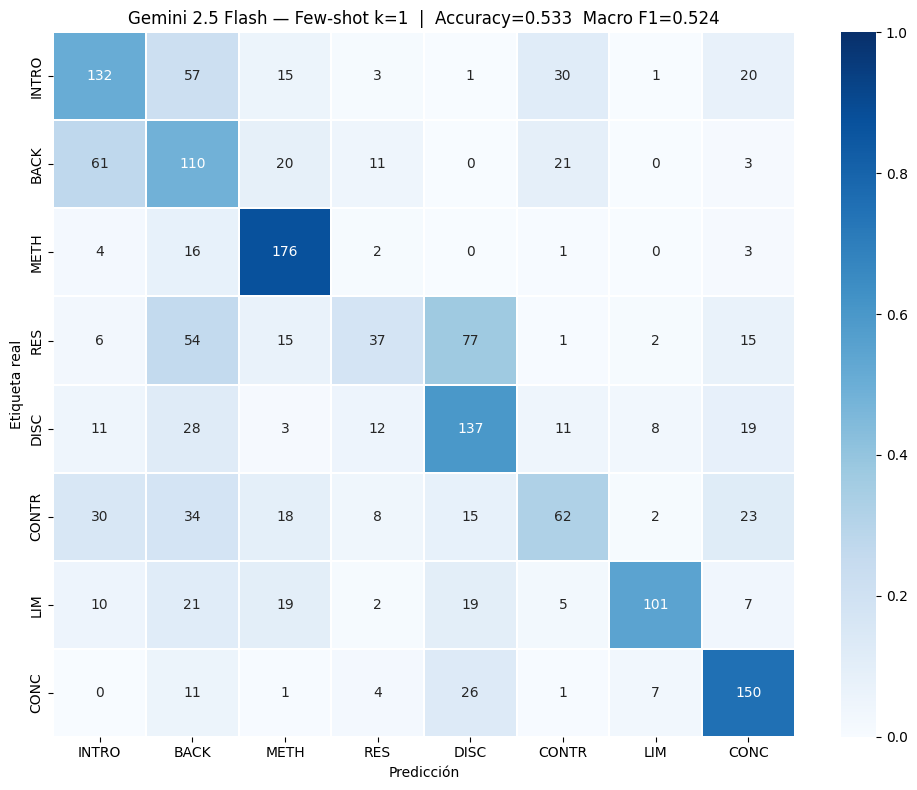

In [13]:
cm      = confusion_matrix(y_true, y_pred, labels=LABELS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm, annot=cm, fmt="d", cmap="Blues",
    xticklabels=LABELS, yticklabels=LABELS,
    vmin=0, vmax=1, ax=ax, linewidths=0.3,
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta real")
ax.set_title(f"Gemini 2.5 Flash — Few-shot k=1  |  Accuracy={acc:.3f}  Macro F1={maf1:.3f}")
plt.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
total_in  = preds["tokens_in"].sum()
total_out = preds["tokens_out"].sum()
cost_usd  = (total_in / 1e6) * COST_INPUT_PER_M + (total_out / 1e6) * COST_OUTPUT_PER_M
lat       = preds["latency_s"]

print(f"Tokens entrada:     {total_in:,}")
print(f"Tokens salida:      {total_out:,}")
print(f"Costo total USD:    ${cost_usd:.4f}")
print(f"Costo/1000 docs:    ${cost_usd / len(preds) * 1000:.4f} USD")
print(f"Latencia media:     {lat.mean():.2f} s")
print(f"Latencia p95:       {lat.quantile(0.95):.2f} s")

Tokens entrada:     16,903,719
Tokens salida:      74,094
Costo total USD:    $5.2564
Costo/1000 docs:    $3.0938 USD
Latencia media:     7.22 s
Latencia p95:       61.88 s


In [15]:
import pandas as pd

summary = pd.DataFrame([{
    "Modelo":             MODEL,
    "Estrategia":         "few-shot k=1",
    "N eval":             len(preds),
    "Requests válidos":   len(valid),
    "Requests fallidos":  failed,
    "Accuracy":           round(acc, 4),
    "Macro F1":           round(maf1, 4),
    "Micro F1":           round(mif1, 4),
    "Costo USD":          round(cost_usd, 4),
    "Latencia media s":   round(lat.mean(), 2),
}])

summary.to_csv(RESULTS_DIR / "summary_a6.csv", index=False)
print(summary.to_string(index=False))
print(f"\nGuardado: {RESULTS_DIR / 'summary_a6.csv'}")

          Modelo   Estrategia  N eval  Requests válidos  Requests fallidos  Accuracy  Macro F1  Micro F1  Costo USD  Latencia media s
gemini-2.5-flash few-shot k=1    1699              1699                  0    0.5327    0.5237    0.5327     5.2564              7.22

Guardado: /content/drive/MyDrive/results_a6_v4/summary_a6.csv
